#***EDA Healthcare data***
**Analyzing synthetic healthcare data created by chatgpt.**

**PROMPT:**

Act as a senior data analyst and dataset engineer.

Generate a realistic, dirty dataset for healthcare. Dataset requirements:

- Number of rows: 500
- Columns needed: 10 - Data type for each column: [number, date, category]
- Realistic distributions and patterns (no random assumptions)
- Include real-world inconsistencies where necessary (missing values, duplicates, typos, outliers) if relevant.

**Output format:**
- Present as a clean table
- Make column names clear and professional
- Ensure the data is realistic and logically consistent

**Extra:**
- Briefly explain the business context behind the data
- Suggest 5–10 analysis questions that can be answered from the dataset.

*Thanks to [@ezekiel_aleke](https://x.com/ezekiel_aleke) for the base prompt*



In [1]:
import pandas as pd

In [2]:
health = pd.read_csv('healthcare_dataset_500.csv')

In [3]:
health.head(10)

,PatientID,VisitDate,AgeYears,Sex,DiagnosisCode,SystolicBP_mmHg,DiastolicBP_mmHg,HeartRate_bpm,MedicationPrescribed,BillingAmount_MXN
0,1064,2024-04-26 06:59:55,24,Female,J06,129.0,85.0,71.0,ibuprofen,295.83
1,1013,2025-11-08 11:33:55,55,Female,J06,126.0,75.0,83.0,amoxicillin,437.15
2,1055,2025-06-05 19:21:49,12,Female,k21,122.0,71.0,75.0,NaN,460.83
3,1018,2025-05-23 10:18:56,39,Male,R07,127.0,64.0,73.0,ibuprofenn,524.00
4,1167,2024-06-06 03:59:33,59,Female,N39,143.0,97.0,87.0,metformin,715.75
5,1098,2025-02-15 12:24:01,62,Female,E11,141.0,78.0,74.0,lisinopril,526.27
6,1194,2024-06-29 09:42:06,47,Female,E66,136.0,91.0,66.0,atorvastatin,455.24
7,1187,2025-05-21 02:55:50,10,Female,R07,127.0,64.0,86.0,ibuprofen,617.31
8,1051,2025-09-29 17:16:36,48,Male,E66,124.0,84.0,66.0,ibuprofen,706.31
9,1176,2024-07-25 03:21:11,47,Female,M54,130.0,83.0,73.0,lisinopri,641.21


In [4]:
health.isnull().sum()

,0
PatientID,0
VisitDate,0
AgeYears,0
Sex,0
DiagnosisCode,14
SystolicBP_mmHg,15
DiastolicBP_mmHg,0
HeartRate_bpm,0
MedicationPrescribed,15
BillingAmount_MXN,15


In [5]:
## rows with NA values

health[health.isna().any(axis=1)]

,PatientID,VisitDate,AgeYears,Sex,DiagnosisCode,SystolicBP_mmHg,DiastolicBP_mmHg,HeartRate_bpm,MedicationPrescribed,BillingAmount_MXN
2,1055,2025-06-05 19:21:49,12,Female,k21,122.000000,71.000000,75.0,NaN,460.83
24,1061,2025-03-12 18:54:48,40,Female,F41,111.000000,78.000000,76.0,NaN,285.16
30,1164,2025-02-09 17:34:36,50,Female,I10,155.571754,92.139747,66.0,none,NaN
40,1041,2025-05-10 16:30:17,37,Female,I10,NaN,85.732909,69.0,ibuprofen,407.02
59,1117,2024-03-21 08:07:25,18,Female,K21,NaN,79.000000,60.0,Metformn,497.40
70,1147,2026-02-07 01:22:56,58,Female,I10,165.955820,92.167285,72.0,NaN,426.20
74,1098,2024-11-05 01:53:45,53,Male,J06,NaN,63.000000,71.0,metformin,431.67
120,1165,2024-06-11 04:36:43,46,Male,I10,136.875208,97.918893,80.0,lisinopril,NaN
125,1048,2025-04-05 20:08:57,53,Male,M54,144.000000,94.000000,79.0,NaN,506.18
131,1148,2025-05-25 19:00:55,56,Male,G43,NaN,90.000000,76.0,amoxicillin,527.06


In [6]:
print(health.columns[health.isna().any()].to_list())

['DiagnosisCode', 'SystolicBP_mmHg', 'MedicationPrescribed', 'BillingAmount_MXN']


In [7]:
healthcare = health.dropna()

In [8]:
healthcare.shape

(443, 10)

In [9]:
healthcare.describe()


,PatientID,AgeYears,SystolicBP_mmHg,DiastolicBP_mmHg,HeartRate_bpm,BillingAmount_MXN
count,443.000000,443.000000,443.000000,443.000000,443.000000,443.000000
mean,1098.981941,44.013544,133.566235,79.673874,73.376975,513.905169
std,58.094514,21.859895,15.804178,9.399446,8.353075,454.858564
min,1000.000000,0.000000,91.000000,53.000000,50.000000,159.880000
25%,1049.000000,29.000000,122.000000,72.000000,68.000000,378.110000
50%,1097.000000,47.000000,133.389680,80.000000,73.000000,456.330000
75%,1147.000000,60.000000,145.000000,86.000000,79.000000,552.850000
max,1198.000000,95.000000,177.708690,105.387881,97.000000,6804.200000


In [16]:
# --- 1. Bin ages into groups ---
bins   = [0,  18,   65,   float('inf')]
labels = ['Pediatric (0-17)', 'Adult (18-64)', 'Senior (65+)']
healthcare['age_group'] = pd.cut(healthcare['AgeYears'], bins=bins, labels=labels, right=False)

/tmp/ipykernel_507/1623216266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare['age_group'] = pd.cut(healthcare['AgeYears'], bins=bins, labels=labels, right=False)


In [20]:
healthcare.columns

Index(['PatientID', 'VisitDate', 'AgeYears', 'Sex', 'DiagnosisCode',
       'SystolicBP_mmHg', 'DiastolicBP_mmHg', 'HeartRate_bpm',
       'MedicationPrescribed', 'BillingAmount_MXN', 'age_group'],
      dtype='object')

In [21]:
# --- 2. Count diagnoses per age group ---
counts = (
    healthcare.groupby(['age_group', 'DiagnosisCode'], observed=True)
      .size()
      .reset_index(name='count')
)


In [23]:
# --- 3. Rank within each group ---
counts['rank'] = (
    counts.groupby('age_group', observed=True)['count']
          .rank(method='dense', ascending=False)
          .astype(int)
)

In [25]:
# --- 4. Keep Top-N per group (e.g. Top 5) ---
TOP_N = 5
top_diagnoses = (
    counts[counts['rank'] <= TOP_N]
          .sort_values(['age_group', 'rank'])
          .reset_index(drop=True)
)

print(top_diagnoses)

           age_group DiagnosisCode  count  rank
0   Pediatric (0-17)           I10     12     1
1   Pediatric (0-17)           M54     11     2
2   Pediatric (0-17)           J06     10     3
3   Pediatric (0-17)           N39      8     4
4   Pediatric (0-17)           E11      7     5
5      Adult (18-64)           J06     66     1
6      Adult (18-64)           I10     46     2
7      Adult (18-64)           E66     38     3
8      Adult (18-64)           M54     37     4
9      Adult (18-64)           E11     35     5
10      Senior (65+)           E66     16     1
11      Senior (65+)           J06     13     2
12      Senior (65+)           N39     11     3
13      Senior (65+)           I10      9     4
14      Senior (65+)           M54      9     4
15      Senior (65+)           K21      7     5


In [28]:
# --- 5. Pivot for a clean side-by-side comparison ---
pivot = (
    top_diagnoses.pivot_table(
        index='rank',
        columns='age_group',
        values='DiagnosisCode',
        aggfunc='first'   # one diagnose per rank cell
    )
)
print(pivot)

age_group Pediatric (0-17) Adult (18-64) Senior (65+)
rank                                                 
1                      I10           J06          E66
2                      M54           I10          J06
3                      J06           E66          N39
4                      N39           M54          I10
5                      E11           E11          K21


/tmp/ipykernel_507/3877890104.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  top_diagnoses.pivot_table(


TypeError: unsupported operand type(s) for &: 'Axes' and 'Axes'

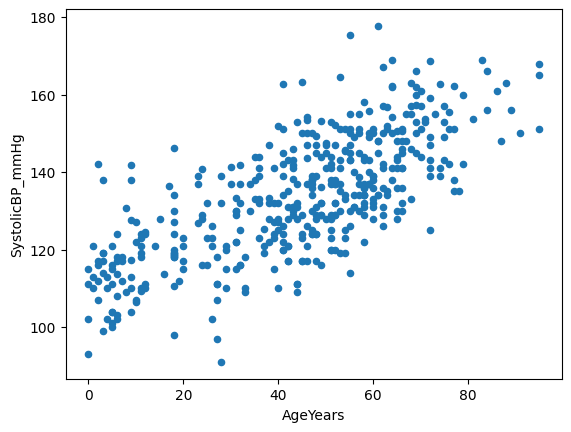

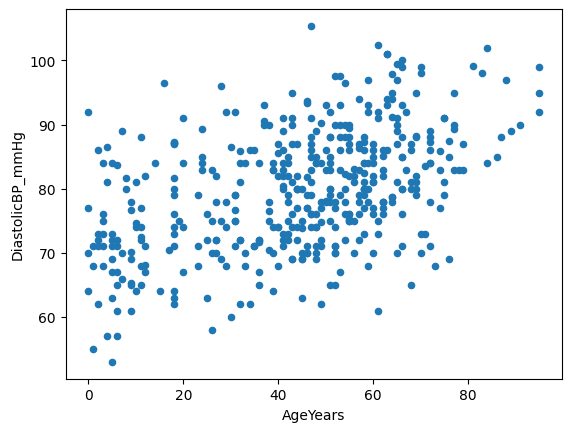

In [60]:
healthcare.plot.scatter(x='AgeYears', y='SystolicBP_mmHg')

<Axes: xlabel='AgeYears', ylabel='DiastolicBP_mmHg'>

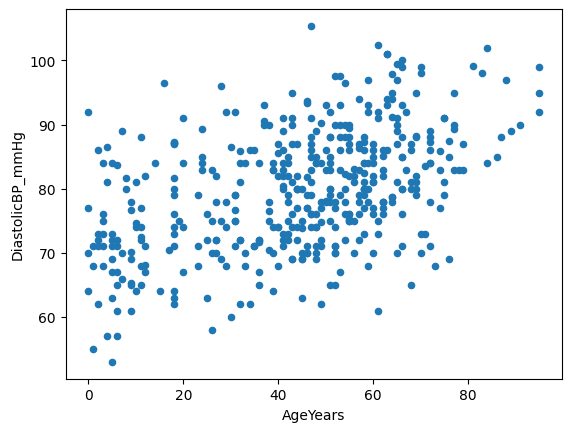

In [59]:
healthcare.plot.scatter(x='AgeYears', y='DiastolicBP_mmHg')

In [29]:
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
Index: 443 entries, 0 to 498
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   PatientID             443 non-null    int64   
 1   VisitDate             443 non-null    object  
 2   AgeYears              443 non-null    int64   
 3   Sex                   443 non-null    object  
 4   DiagnosisCode         443 non-null    object  
 5   SystolicBP_mmHg       443 non-null    float64 
 6   DiastolicBP_mmHg      443 non-null    float64 
 7   HeartRate_bpm         443 non-null    float64 
 8   MedicationPrescribed  443 non-null    object  
 9   BillingAmount_MXN     443 non-null    float64 
 10  age_group             443 non-null    category
dtypes: category(1), float64(4), int64(2), object(4)
memory usage: 54.8+ KB


In [33]:
healthcare['Sex'].value_counts()

,count
Sex,
Female,228
Male,212
Other,3


In [44]:
avgage = healthcare['AgeYears'].mean().round()
print(f'La edad promedio es: {avgage} años')

La edad promedio es: 44.0 años


In [46]:
medianage = healthcare['AgeYears'].median()
print(f'La edad mediana es: {medianage} años')


La edad mediana es: 47.0 años


In [50]:
pediatric = healthcare[(healthcare['AgeYears'] > 0) & (healthcare['AgeYears'] < 18)]

In [51]:
pediatric.describe()

,PatientID,AgeYears,SystolicBP_mmHg,DiastolicBP_mmHg,HeartRate_bpm,BillingAmount_MXN
count,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000
mean,1097.142857,7.174603,116.203016,72.115381,73.079365,607.444444
std,60.859398,3.945351,10.084045,8.719415,8.207592,830.313006
min,1003.000000,1.000000,99.000000,53.000000,57.000000,249.100000
25%,1044.000000,4.000000,110.000000,67.000000,66.000000,371.555000
50%,1097.000000,6.000000,116.000000,71.000000,73.000000,473.660000
75%,1151.000000,10.000000,121.000000,76.864919,79.000000,594.175000
max,1195.000000,17.000000,142.000000,96.424867,90.000000,6804.200000


In [52]:
adults = healthcare[(healthcare['AgeYears'] >= 18) & (healthcare['AgeYears'] < 60)]

In [53]:
adults.describe()

,PatientID,AgeYears,SystolicBP_mmHg,DiastolicBP_mmHg,HeartRate_bpm,BillingAmount_MXN
count,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
mean,1100.391635,42.581749,132.012757,79.147530,73.665399,495.241901
std,56.880706,11.642577,12.870201,8.310741,8.895611,304.963575
min,1000.000000,18.000000,91.000000,58.000000,50.000000,159.880000
25%,1052.500000,35.000000,123.000000,73.000000,68.000000,367.115000
50%,1096.000000,45.000000,132.000000,79.000000,73.000000,449.790000
75%,1147.000000,52.000000,141.000000,85.000000,80.000000,553.320000
max,1198.000000,59.000000,175.271543,105.387881,97.000000,3530.100000


In [54]:
seniors = healthcare[healthcare['AgeYears'] >= 60]

In [55]:
seniors.describe()

,PatientID,AgeYears,SystolicBP_mmHg,DiastolicBP_mmHg,HeartRate_bpm,BillingAmount_MXN
count,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000
mean,1097.088496,69.442478,147.864574,85.251830,72.920354,505.883186
std,59.527688,8.386786,11.366598,8.739569,7.176526,459.737524
min,1000.000000,60.000000,125.000000,61.000000,60.000000,213.310000
25%,1049.000000,63.000000,139.000000,80.000000,68.000000,385.910000
50%,1098.000000,67.000000,148.000000,85.000000,73.000000,456.330000
75%,1145.000000,74.000000,156.000000,91.000000,77.000000,527.180000
max,1198.000000,95.000000,177.708690,102.464986,92.000000,5196.400000


In [62]:
womenmask = healthcare['Sex'] == 'Female'
women = healthcare[womenmask]

menmask = healthcare['Sex'] == 'Male'
men = healthcare[menmask]

<Axes: xlabel='AgeYears', ylabel='SystolicBP_mmHg'>

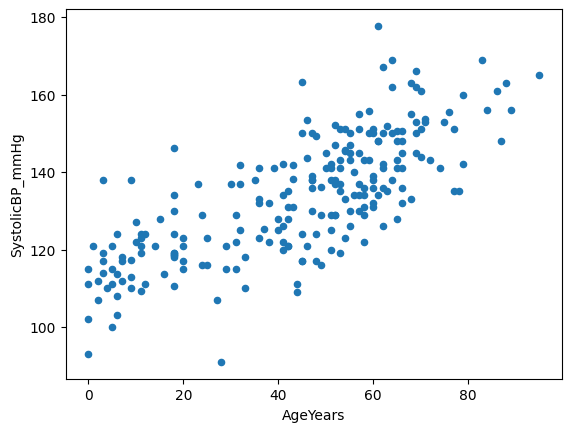

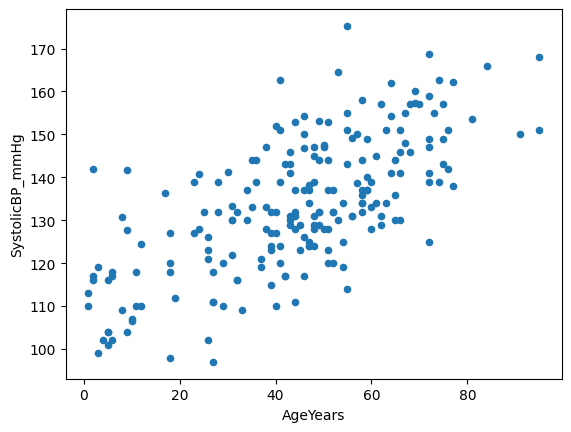

In [64]:
women.plot.scatter(x='AgeYears', y='SystolicBP_mmHg')
men.plot.scatter(x='AgeYears', y='SystolicBP_mmHg')
